# 04 – Linear Regression Forecasting

In this notebook we train a first interpretable forecasting model using
linear regression and time-based features.  
Model performance is evaluated using walk-forward validation.

## 1. Imports and configurations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

## 2. Load feature-engineered dataset

In [2]:
data_path = "../data/processed/electricity_hourly_features.csv"

df = pd.read_csv(
    data_path,
    parse_dates=["timestamp"],
    index_col="timestamp"
)

df.head()

,load_mw,hour,dayofweek,day,month,is_weekend,lag_1,lag_2,lag_3,lag_6,...,lag_48,lag_168,rolling_mean_3,rolling_std_3,rolling_mean_6,rolling_std_6,rolling_mean_12,rolling_std_12,rolling_mean_24,rolling_std_24
timestamp,,,,,,,,,,,,,,,,,,,,,
2002-01-08 01:00:00,29445.0,1,1,8,1,0,31187.0,33579.0,35997.0,39581.0,...,27100.0,30393.0,33587.666667,2405.011712,36150.166667,3243.473719,36247.583333,2390.029002,33452.583333,4559.767709
2002-01-08 02:00:00,28670.0,2,1,8,1,0,29445.0,31187.0,33579.0,38780.0,...,26097.0,29265.0,31403.666667,2075.499297,34460.833333,3705.837796,35718.833333,3097.586504,33560.208333,4425.965952
2002-01-08 03:00:00,28375.0,3,1,8,1,0,28670.0,29445.0,31187.0,37777.0,...,25793.0,28357.0,29767.333333,1289.087403,32775.833333,3647.173394,35141.833333,3707.741087,33672.458333,4256.159403
2002-01-08 04:00:00,28542.0,4,1,8,1,0,28375.0,28670.0,29445.0,35997.0,...,25657.0,27899.0,28830.000000,552.652694,31208.833333,3037.502291,34545.833333,4184.385169,33786.375000,4064.104959
2002-01-08 05:00:00,29261.0,5,1,8,1,0,28542.0,28375.0,28670.0,33579.0,...,25778.0,28057.0,28529.000000,147.929037,29966.333333,2052.058641,33966.916667,4509.934377,33906.208333,3851.076461


## 3. Feature matrix and target

In [3]:
target = "load_mw"

feature_cols = [
    col for col in df.columns if col != target
]

X = df[feature_cols]
y = df[target]

## 4. Walk-forward validation

We simulate a realistic forecasting scenario by retraining the model
as new data becomes available.

In [4]:
def walk_forward_validation(X, y, model, initial_train_size, horizon=1, step=24):
    predictions = []
    actuals = []
    timestamps = []

    for i in range(initial_train_size, len(X) - horizon, step):
        X_train = X.iloc[:i]
        y_train = y.iloc[:i]

        X_test = X.iloc[i:i+horizon]
        y_test = y.iloc[i:i+horizon]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        predictions.extend(y_pred)
        actuals.extend(y_test.values)
        timestamps.extend(y_test.index)

    return pd.Series(predictions, index=timestamps), pd.Series(actuals, index=timestamps)

Walk-forward validation is performed using daily updates to balance realism and computational efficiency.

## 5. Train and evaluate linear regression model

In [5]:
initial_train_size = int(len(X) * 0.6)

model = LinearRegression()

y_pred, y_true = walk_forward_validation(X, y, model, initial_train_size)

## 6. Model performance

In [6]:
mae = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred, squared=False)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE:  349.65
RMSE: 475.52


## 7. Forecast vs actual values

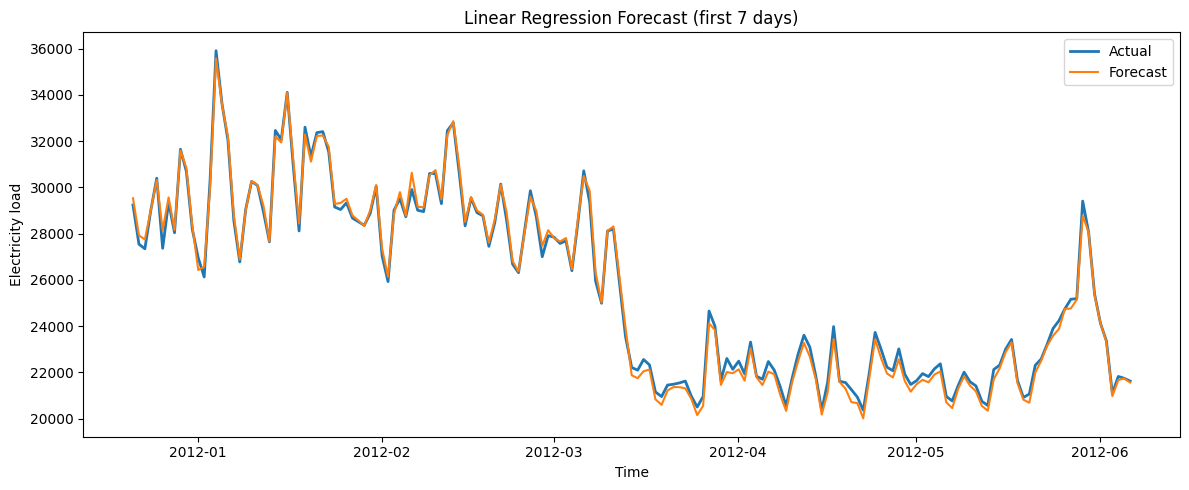

In [7]:
plt.figure(figsize=(12, 5))

plt.plot(y_true.index[:168], y_true[:168], label="Actual", linewidth=2)
plt.plot(y_pred.index[:168], y_pred[:168], label="Forecast")

plt.title("Linear Regression Forecast (first 7 days)")
plt.xlabel("Time")
plt.ylabel("Electricity load")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Feature importance

Linear regression coefficients provide a simple form of interpretability.

In [8]:
model.fit(X.iloc[:initial_train_size], y.iloc[:initial_train_size])

coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": model.coef_
}).sort_values(by="coefficient", key=np.abs, ascending=False)

coef_df

,feature,coefficient
1,dayofweek,-42.439616
4,is_weekend,-18.126681
0,hour,-14.090296
5,lag_1,1.857072
6,lag_2,-1.341185
15,rolling_mean_6,-0.835597
7,lag_3,0.560133
13,rolling_mean_3,0.358673
3,month,-0.329975
17,rolling_mean_12,0.290659


## 9. Interpretation and next steps

- The linear model improves upon naive baselines by leveraging temporal features.
- Coefficients confirm the importance of daily and weekly seasonality.
- While simple, this model provides a strong and interpretable benchmark.

Next steps could include:
- Regularized linear models (Ridge / Lasso)
- Tree-based models
- Probabilistic forecasting